### Imports

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

### Helper Functions

In [2]:
#helper function for stripping white space from names and matching it
#regrettably we need to use this to match the wiki/trends data
def name_cleaner(name):
    return (
        name.fillna('')
         .str.lower()
         #drop punctuation
         .str.replace(r'[^a-z0-9\s]', '', regex=True)
         #remove multiple white spaces
         .str.replace(r'\s+', ' ', regex=True)
         .str.strip()
    )

#cleans out products which are not actually games
#items can be listed if they are an explansion or some other add-on for a base product
#really we are more interested in the base products themselves.
def cat_cleaner(df):
    bad_cats = {
    'Expansion for Base-game',
    'Book',
    'Game System',
    'Third-party Expansion',
    'Fan Expansion'}


    return df[
        #needed to check the data type here. some games came back with a nan for category
        ~df['categories'].apply(
            lambda x: (
                isinstance(x, str)
                and any(c in bad_cats for c in x.split(', '))
            )
        )
    ]



### Load in Bronze datasets

In [3]:
#load in primary source data
trends_df = pd.read_csv('data/data_sources_bronze/trends_20260527.csv')
wiki_df = pd.read_csv('data/data_sources_bronze/awards_dataset_20260516.csv')
bgg_df = pd.read_csv('data/data_sources_bronze/bgg_dataset_20260527.csv')
price_df = pd.read_csv('data/data_sources_bronze/bgg_marketplace_20260527.csv')

#pivot trend data to make it match the wiki data.
trends_df = trends_df.melt(
    id_vars=['year'],
    var_name='game_name',
    value_name='trend_value'
)

In [4]:
bgg_df

,id,name,year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,avg_rating,...,num_owned,num_comments,num_wanting,num_wishing,categories,mechanics,designers,publishers,families,num_logged
0,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,8.56401,...,84099,7961,1746,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",NaN
1,342942,Ark Nova,2021,1,4,90,150,14,3.7967,8.54046,...,88969,8078,1063,17786,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...",Mathias Wigge,"Feuerland Spiele, Capstone Games, CMON Global ...","Animals: Okapi, Components: Hexagonal Tiles, C...",NaN
2,161936,Pandemic Legacy: Season 1,2015,2,4,60,60,13,2.8279,8.50231,...,89397,8605,813,15039,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Rob Daviau, Matt Leacock","Z-Man Games, Asterion Press, Devir, Filosofia ...","Components: Map (Global Scale), Components: Mu...",NaN
3,174430,Gloomhaven,2017,1,4,60,120,14,3.9192,8.53879,...,104567,11724,1161,22312,"Adventure, Exploration, Fantasy, Fighting, Min...","Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci...",NaN
4,397598,Dune: Imperium – Uprising,2023,1,6,60,120,13,3.5224,8.70045,...,28509,2351,891,7872,"Movies / TV / Radio theme, Novel-based, Scienc...","Automatic Resource Growth, Card Play Conflict ...",Paul Dennen,"Dire Wolf, Arclight Games, Broadway Toys LTD, ...","Books: Dune, Game: Dune: Imperium, Misc: LongP...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176950,29091,Whatchamacallit Word Game,1983,2,6,40,40,0,0.0000,6.50000,...,6,1,1,0,"Educational, Word Game","Paper-and-Pencil, Tile Placement",(Uncredited),"Crown & Andrews Ltd., Peter Pan Playthings",Components: 12 x 14 Grids,NaN
176951,29092,Picco Camillo,2005,2,6,15,15,4,1.1250,5.64286,...,16,2,1,0,Children's Game,NaN,Reiner Knizia,Selecta Spielzeug,NaN,NaN
176952,29093,Een Reis Door Nederland,1980,2,6,45,45,9,0.0000,5.26250,...,45,6,0,0,"Educational, Transportation, Travel","Point to Point Movement, Roll / Spin and Move",C. J. Kelfkens,Otto Maier Verlag,"Admin: Better Description Needed!, Country: Ne...",NaN
176953,29094,Würfel Kick,2006,2,2,15,15,8,0.0000,5.00000,...,9,2,0,1,Sports,"Dice Rolling, Point to Point Movement",Wolfgang Riedesser,Ravensburger AG,"Players: Two-Player Only Games, Sports: Footba...",NaN


### Clean up some junk values \(price\_df / trends\_df\)

In [5]:
#drop some crazy high listings for products. some may be reasonable for collector's items,
#but we are more interested in the product's quality. We only lose 3,745 records this way
price_df = price_df[
    (price_df['price_usd'] > 1) & 
    (price_df['price_usd'] < 500)
]

#drop some junk, by-product rows of the google trends datas collection process/ 0 values
trends_df = trends_df[~trends_df['game_name'].str.contains('Unnamed')]
trends_df = trends_df[trends_df['trend_value'] != 0]

### Clean up bgg dataset \(lots of wacky stuff here\!\)

In [6]:
#replaced some 0 values here which make no sense.
bgg_df['min_players'] = bgg_df['min_players'].replace(0, 1)
bgg_df['max_players'] = bgg_df['max_players'].replace(0, 1)
bgg_df['min_playtime'] = bgg_df['min_playtime'].replace(0, 1)
bgg_df['max_playtime'] = bgg_df['max_playtime'].replace(0, 1)

#normalized other values. min/max values should make sense within their contexts.
bgg_df.loc[bgg_df['min_players'] > bgg_df['max_players'], 'max_players'] = bgg_df['min_players']
bgg_df.loc[bgg_df['min_playtime'] > bgg_df['max_playtime'], 'max_playtime'] = bgg_df['min_playtime']

#dropped a few extreme values here. this might look scary, but we only lose 73 records in total.
bgg_df = bgg_df[bgg_df['max_playtime'] < 6000]
bgg_df = bgg_df[bgg_df['max_players'] < 1000]

#this might be a bit controversial of a decision. I'm assuming that the year 0 is a data error
#or someone being lazy most of the time.
bgg_df.loc[bgg_df['year'] == 0, 'year'] = bgg_df['year'].median()

#a lot of games here centered around drinking, drugs, and other adult records for
#things i dont care to validate, particularly on my work machine.
#to be safe we will presume that 21 is the max age of any game listed over 21.
bgg_df.loc[bgg_df['min_age'] > 21, 'min_age'] = 21

#101,899 records returned with 0 complextiy. The BGG things dataset has 176,882 records,
#so that is a significant number of the results we returned.
bgg_df.loc[bgg_df['complexity'] == 0, 'complexity'] = bgg_df['complexity'].mean()

#134,193 records returned with 0 bayes-average shifted those to the mean instead too.
bgg_df.loc[bgg_df['bayes_rating'] == 0, 'bayes_rating'] = bgg_df['bayes_rating'].mean()

#drops records indicating a product is not actually a game. we lose 39,368 records here
bgg_df = cat_cleaner(bgg_df)

bgg_df.describe()

,id,year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,avg_rating,bayes_rating,num_ratings,num_owned,num_comments,num_wanting,num_wishing,num_logged
count,137513.000000,137513.000000,137513.000000,137513.000000,137513.00000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,137513.000000,0.0
mean,204385.486230,2005.979602,1.991186,6.922902,35.89425,53.195203,7.808731,1.299069,4.788510,2.350898,219.231418,409.912161,50.554391,9.047843,64.627163,NaN
std,153774.051417,57.670978,0.825992,17.070542,66.94383,118.866056,4.777509,0.736153,2.997851,1.812823,2083.980544,3290.238734,354.812027,51.112072,473.573488,NaN
min,1.000000,-3500.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.842052,0.000000,1.368148,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,40282.000000,2003.000000,2.000000,3.000000,10.00000,15.000000,5.000000,0.842052,2.500000,1.368148,1.000000,2.000000,0.000000,0.000000,0.000000,NaN
50%,184364.000000,2014.000000,2.000000,4.000000,20.00000,30.000000,8.000000,0.842052,5.818180,1.368148,4.000000,10.000000,2.000000,0.000000,2.000000,NaN
75%,345625.000000,2020.000000,2.000000,6.000000,45.00000,60.000000,12.000000,1.666700,6.993280,1.368148,24.000000,71.000000,11.000000,2.000000,11.000000,NaN
max,470593.000000,2030.000000,50.000000,999.000000,5400.00000,5400.000000,21.000000,5.000000,10.000000,8.478530,142362.000000,240477.000000,23919.000000,1980.000000,27088.000000,NaN


### Join datasets and cleanup some columns

In [7]:
#drop some junk, by-product rows of the google trends/bgg/wiki data collection process
trends_df = trends_df[~trends_df['game_name'].str.contains('Unnamed')]

#join the trend and wiki data on year and game_name key
wiki_df['clean_name'] = name_cleaner(wiki_df['game_name'])
wiki_df['key'] = wiki_df['year'].astype(str) + '_' + wiki_df['clean_name']
trends_df['clean_name'] = name_cleaner(trends_df['game_name'])
trends_df['key'] = trends_df['year'].astype(str) + '_' + trends_df['clean_name']
wt_df = wiki_df.merge(trends_df, on='key', how='right')

#cleanup duplicate columns/row names
wt_df = wt_df[['award', 'category', 'key', 'year_y', 'game_name_y', 'trend_value', 'clean_name_y']]
wt_df = wt_df.rename(columns = {'year_y': 'award_year', 'game_name_y': 'game_name', 'clean_name_y': 'clean_name'})

joined_bgg_df = bgg_df.merge(price_df, on='id', how='inner')
joined_bgg_df = joined_bgg_df[
    [
        'id',
        'name_x',
        'year',
        'min_players',
        'max_players',
        'min_playtime',
        'max_playtime',
        'min_age',
        'complexity',
        'avg_rating',
        'bayes_rating',
        'num_ratings',
        'num_owned',
        'num_comments',
        'num_wanting',
        'num_wishing',
        'categories',
        'mechanics',
        'designers',
        'publishers',
        'families',
        'date',
        'price_usd',
        'condition',
        'year_month'
    ]
]
joined_bgg_df = joined_bgg_df.rename(columns = {
    'year': 'publication_year',
    'name_x': 'game_name',
    'date': 'listing_date',
    'year_month': 'listing_year_month',
    })

### Graph joined bgg set to look for outliers

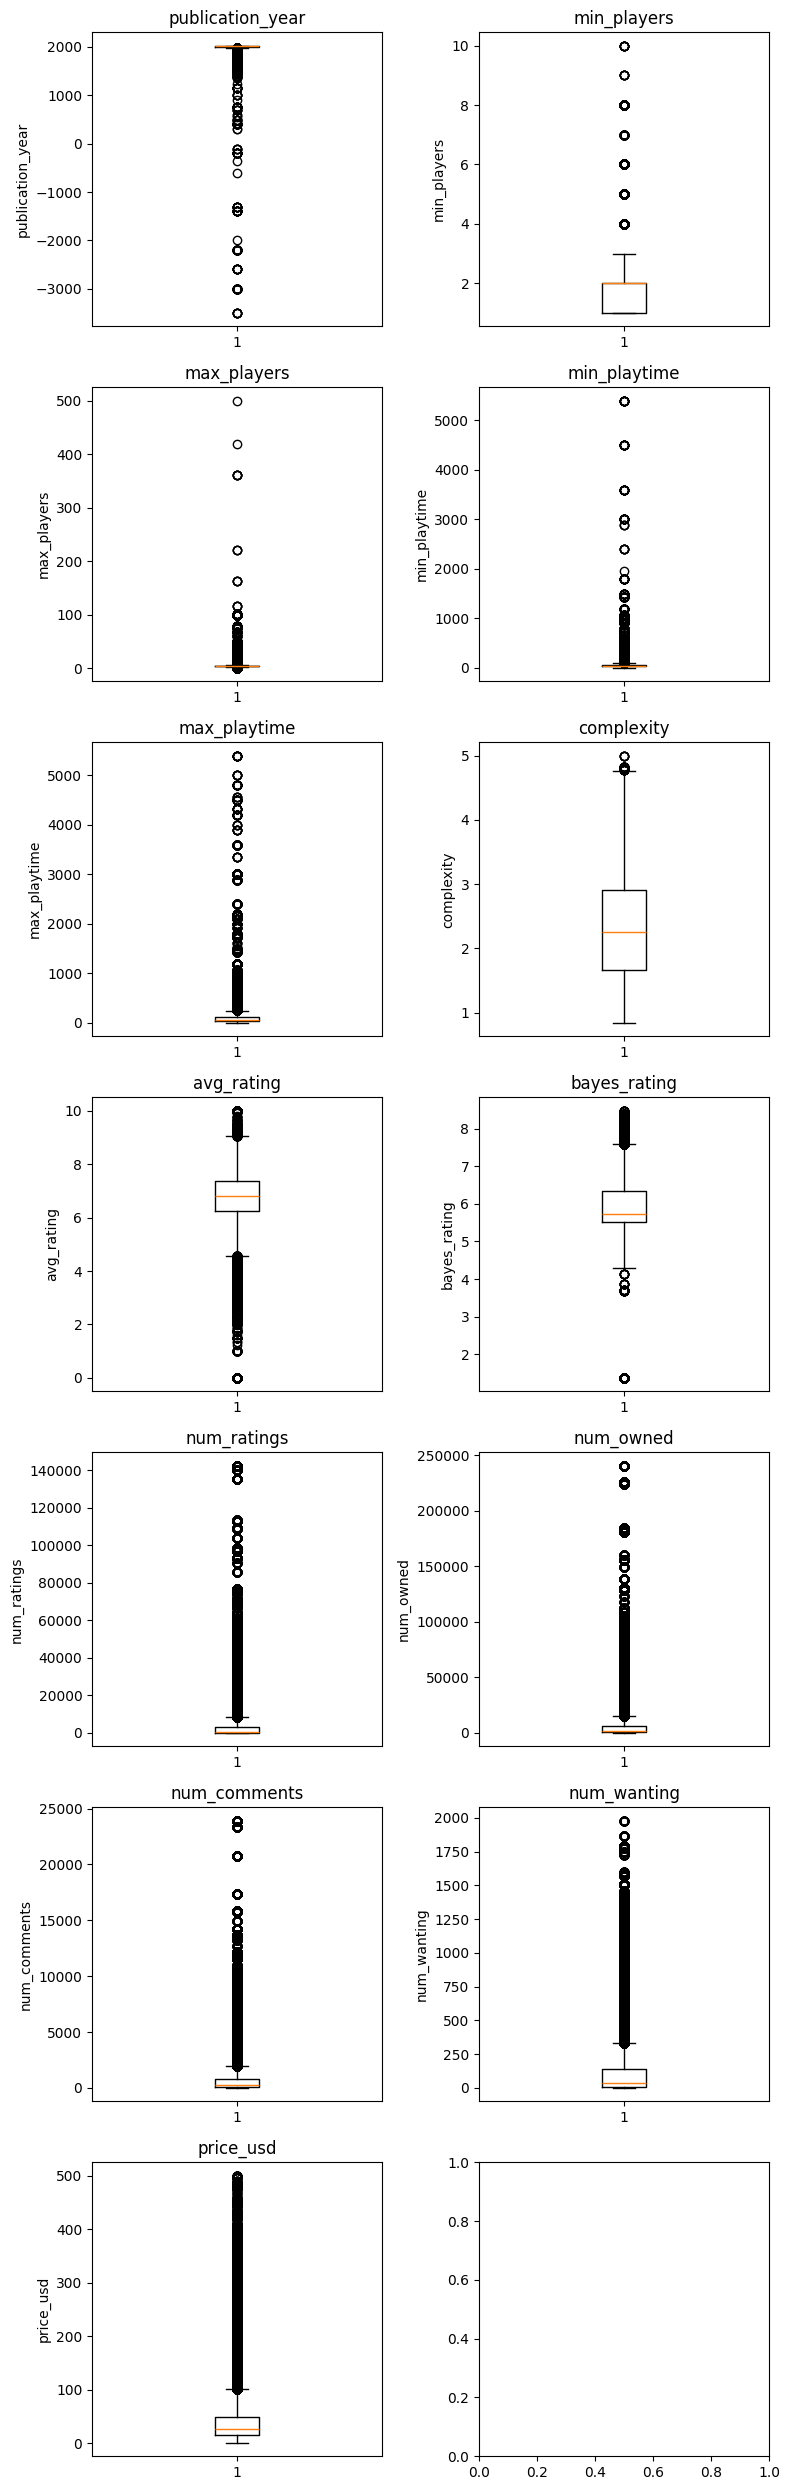

In [8]:
#just checking to see the distribution of each numeric column. had to perform some
#pretty heavy cleanup on the BGG dataset because so much of it is user generated.
#our datasets have some very long tails in places. many of them are heavy on the right side
cols = [
    'publication_year',
    'min_players',
    'max_players',
    'min_playtime',
    'max_playtime',
    'complexity',
    'avg_rating',
    'bayes_rating',
    'num_ratings',
    'num_owned',
    'num_comments',
    'num_wanting',
    'price_usd']

fig, axes = plt.subplots(7, 2, figsize=(8, 25))  # grid layout
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(joined_bgg_df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


### Deposit results for EDA

In [9]:
#finally lets store these guys!
wt_df.to_csv("data/data_sources_silver/wiki_and_trends_20260528.csv")
joined_bgg_df.to_csv("data/data_sources_silver/bgg_and_marketplace_20260528.csv")

#save base, cleaned dataframes to silver folder
bgg_df.to_csv("data/data_sources_silver/clean_bgg.csv")
price_df.to_csv("data/data_sources_silver/clean_price.csv")
trends_df.to_csv("data/data_sources_silver/clean_trends.csv")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b3536b60-e481-4f67-b46c-1c4de87b554b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>